In [19]:
# Preparando o Notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [20]:
# Leitura da tabela fato
     
arquivo = "tabelaFatoVariaveis.xlsx"
sheet = "historicoKPIs"

df = pd.read_excel(arquivo, sheet_name=sheet)

print("Colunas:", df.columns.tolist())
df.head()

Colunas: ['Calendario', 'RS_L_KO', 'Rend_mensal', 'IPCA_TT', 'IPCA_CAFE', 'Taxa_desocupacao', 'Aluminio_LME_d1', 'Aluminio_MWP_d30', 'Acucar_d1', 'Apoio_predito', 'Apoio_Nielsen']


,Calendario,RS_L_KO,Rend_mensal,IPCA_TT,IPCA_CAFE,Taxa_desocupacao,Aluminio_LME_d1,Aluminio_MWP_d30,Acucar_d1,Apoio_predito,Apoio_Nielsen
0,2020-01-01,4.904494,3044.000000,0.210000,-0.230000,0.114000,1772.000,297.623700,0.131300,5.063885,4.904494
1,2020-02-01,4.908891,3047.000000,0.250000,-0.440000,0.118000,1694.500,300.266500,0.148900,5.019132,4.908891
2,2020-03-01,4.888526,3072.000000,0.070000,1.230000,0.124000,1684.500,248.019700,0.138100,4.966230,4.888526
3,2020-04-01,4.863792,3054.333333,0.176667,0.186667,0.118667,1717.000,281.969967,0.139433,5.016415,4.863792
4,2020-05-01,4.856329,3067.250000,0.055000,0.465000,0.120750,1653.625,265.424525,0.129675,4.944735,4.856329


In [21]:
# Tratamento de colunas ajuste se os nomes forem outros)
df.columns = [
    "Calendario",          # A
    "RS_L_KO",             # B (y)
    "Rend_mensal",         # C (x1)
    "IPCA_TT",             # D (x2)
    "IPCA_CAFE",           # E (x3)
    "Taxa_desocupacao",    # F (x4)
    "Aluminio_LME_d1",     # G (x5)
    "Aluminio_MWP_d30",    # H (x6)
    "Acucar_d1",           # I (x7)
    "Apoio_predito",       # J (x8)
    "Apoio_Nielsen"        # K (x9)
]

# Tratamento de variáveis para float
cols_numericas = [
    "RS_L_KO", "Rend_mensal", "IPCA_TT", "IPCA_CAFE",
    "Taxa_desocupacao", "Aluminio_LME_d1", "Aluminio_MWP_d30",
    "Acucar_d1", "Apoio_predito", "Apoio_Nielsen"
]

df[cols_numericas] = df[cols_numericas].apply(pd.to_numeric, errors="coerce")

# Tratando linhas NaN nas variáveis relevantes
df_modelo = df.dropna(subset=cols_numericas).copy()

y = df_modelo["RS_L_KO"]
X = df_modelo[[
    "Rend_mensal", "IPCA_TT", "IPCA_CAFE", "Taxa_desocupacao",
    "Aluminio_LME_d1", "Aluminio_MWP_d30", "Acucar_d1",
    "Apoio_predito", "Apoio_Nielsen"
]]

In [22]:
# Statsmodels (para ver coeficientes, p-valores, etc.)
X_sm = sm.add_constant(X)
modelo_sm = sm.OLS(y, X_sm).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                RS_L_KO   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.566e+05
Date:                Thu, 08 Jan 2026   Prob (F-statistic):          5.49e-112
Time:                        20:03:25   Log-Likelihood:                 260.83
No. Observations:                  55   AIC:                            -503.7
Df Residuals:                      46   BIC:                            -485.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0377      0.024  

In [31]:
# Com sklearn (para treino/teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

print("R² (teste):", r2_score(y_test, y_pred))
#print("RMSE (teste):", mean_squared_error(y_test, y_pred, squared=False)) - tentativa fracassa na função
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE (teste):", rmse)

coef_df = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": reg.coef_
})
print(coef_df)

R² (teste): 0.9999953415357642
RMSE (teste): 0.001402018349080599
           Variavel  Coeficiente
0       Rend_mensal     0.000008
1           IPCA_TT    -0.000336
2         IPCA_CAFE     0.000563
3  Taxa_desocupacao    -0.006928
4   Aluminio_LME_d1     0.000004
5  Aluminio_MWP_d30    -0.000009
6         Acucar_d1    -0.023634
7     Apoio_predito     0.001132
8     Apoio_Nielsen     1.001359


In [32]:
# Coletando variável de dispersão - Coeficiente de Variaçaõ LSS
cv_resultados = {}

for col in cols_numericas:
    media = df_modelo[col].mean()
    desvio = df_modelo[col].std()
    cv = desvio / media if media != 0 else np.nan
    cv_resultados[col] = {
        "media": media,
        "desvio": desvio,
        "cv": cv
    }

cv_df = pd.DataFrame(cv_resultados).T
cv_df.columns = ["Media", "Desvio_padrao", "Coef_variacao"]
cv_df

,Media,Desvio_padrao,Coef_variacao
RS_L_KO,5.695688,0.662392,0.116297
Rend_mensal,3027.065152,122.029942,0.040313
IPCA_TT,0.484439,0.356123,0.735124
IPCA_CAFE,1.109758,2.018691,1.819038
Taxa_desocupacao,0.108839,0.026661,0.244962
Aluminio_LME_d1,2257.563636,437.385951,0.193742
Aluminio_MWP_d30,486.518835,177.607260,0.365057
Acucar_d1,0.182988,0.041075,0.224467
Apoio_predito,5.696931,0.659752,0.115808
Apoio_Nielsen,5.695340,0.661826,0.116205


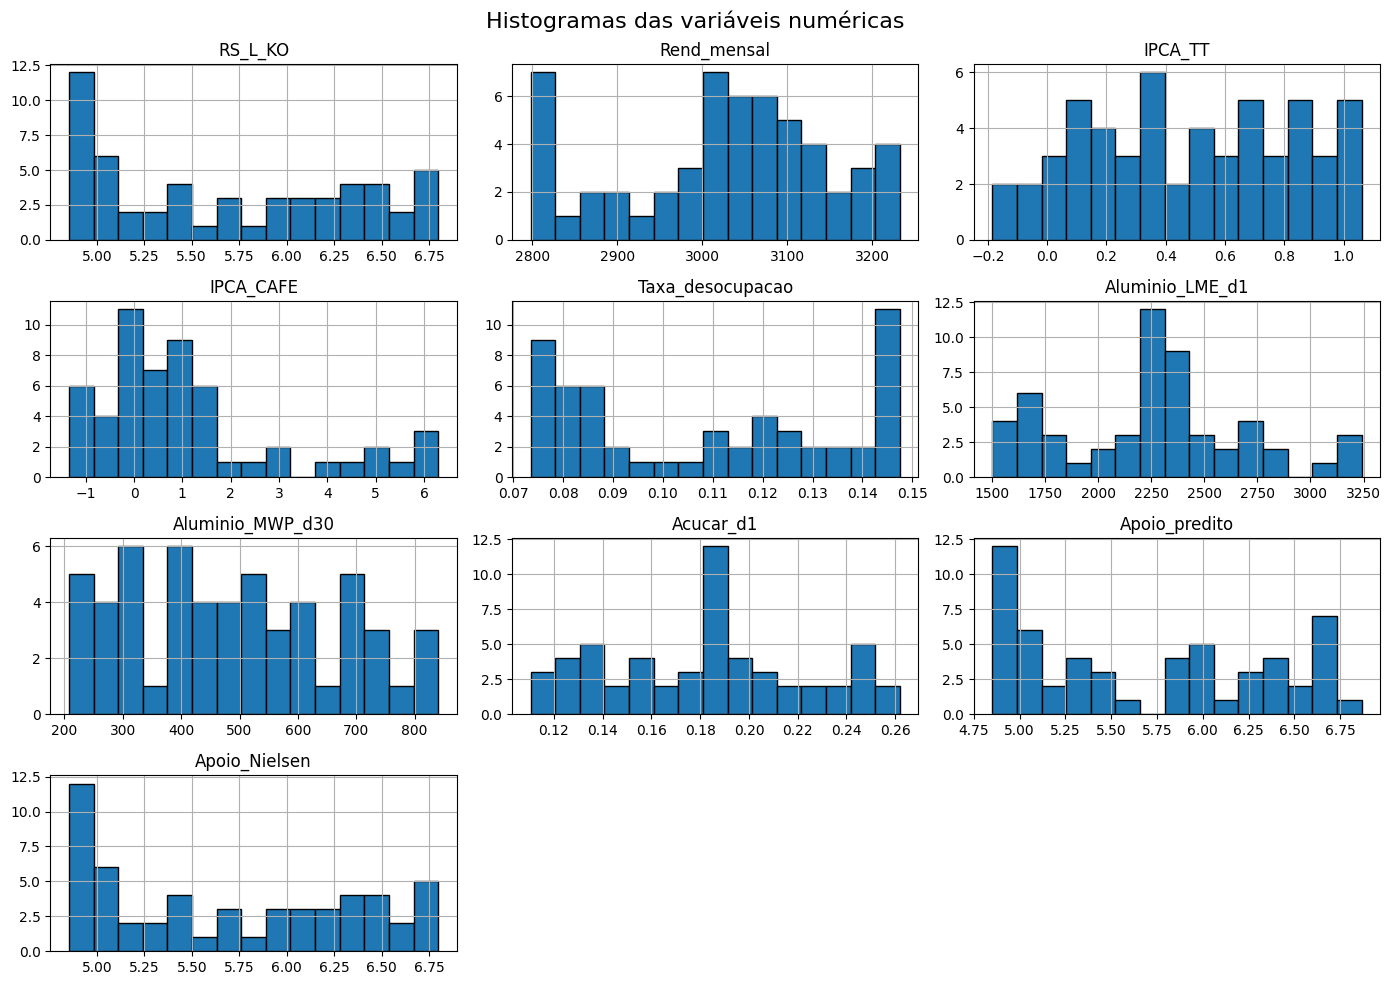

In [33]:
# Coletando visual gráfico de histograma
df_modelo[cols_numericas].hist(
    figsize=(14, 10),
    bins=15,
    edgecolor="black"
)
plt.suptitle("Histogramas das variáveis numéricas", fontsize=16)
plt.tight_layout()
plt.show()

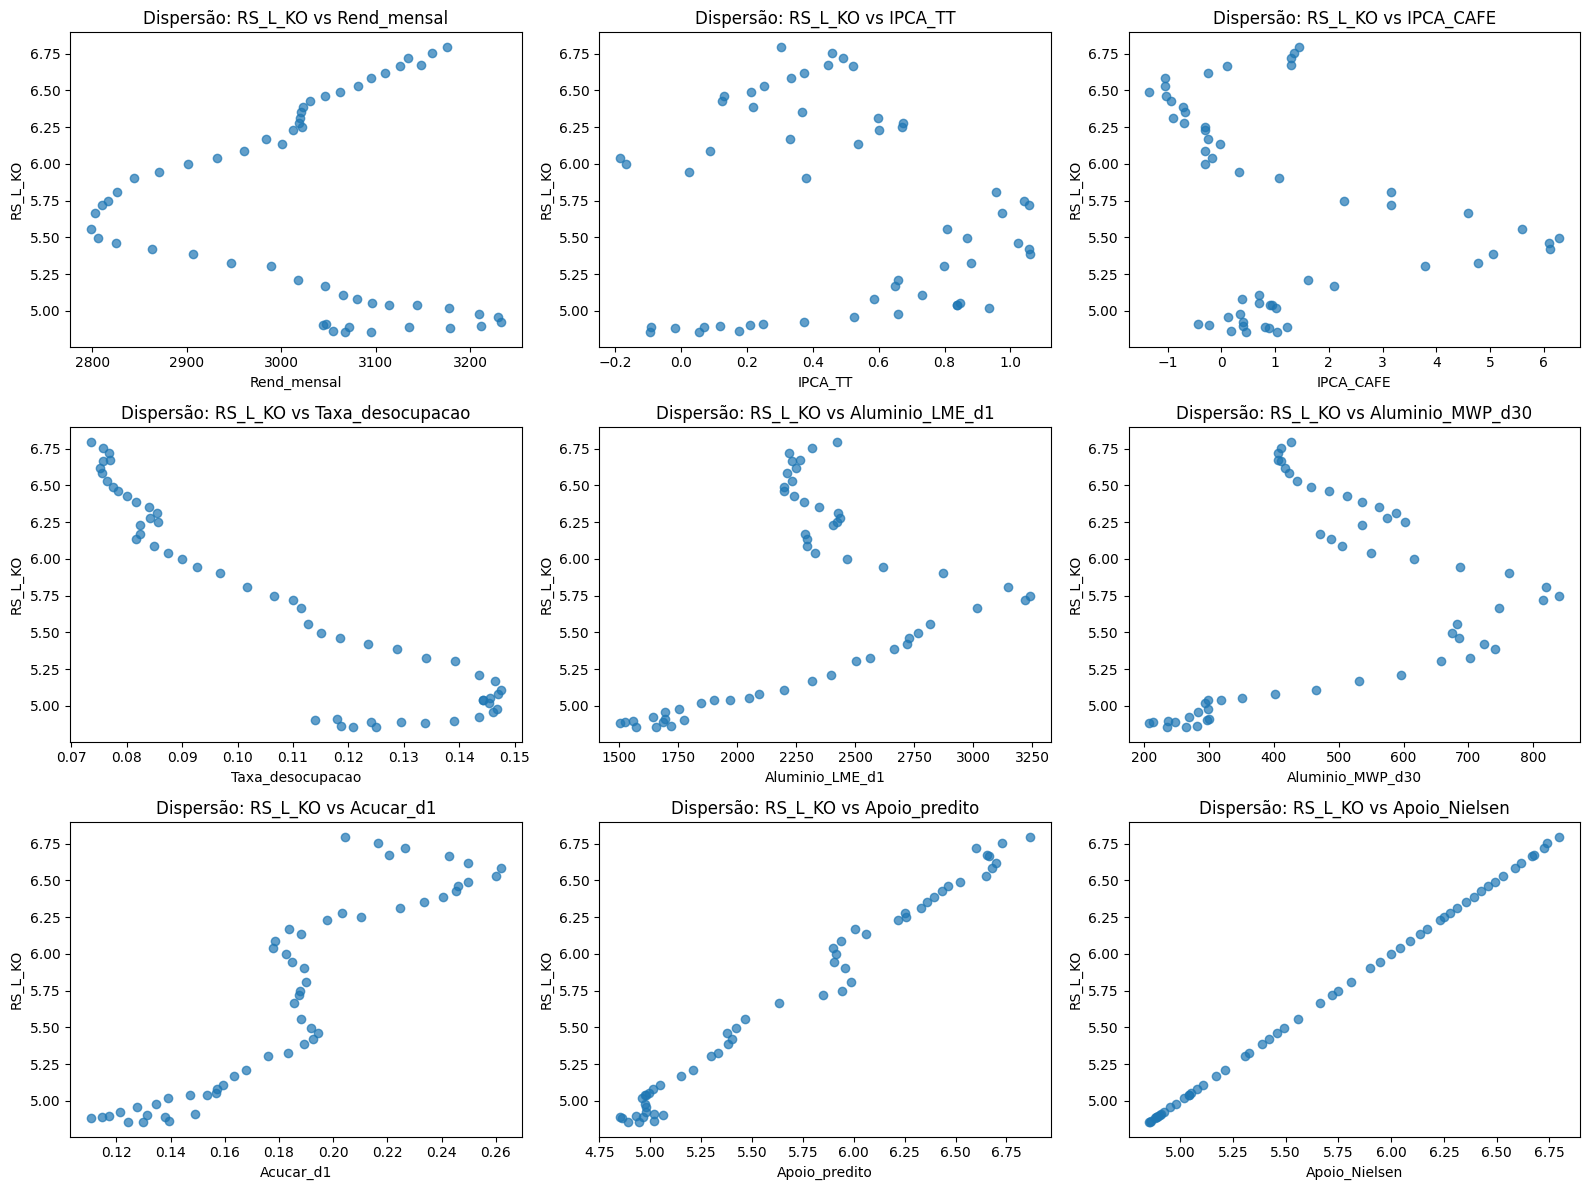

In [34]:
# Coletando dispersão linear para cada variável versus Y predita
plt.figure(figsize=(16, 12))

for i, col in enumerate(X.columns, 1):
    plt.subplot(3, 3, i)
    plt.scatter(df_modelo[col], y, alpha=0.7)
    plt.xlabel(col)
    plt.ylabel("RS_L_KO")
    plt.title(f"Dispersão: RS_L_KO vs {col}")

plt.tight_layout()
plt.show()

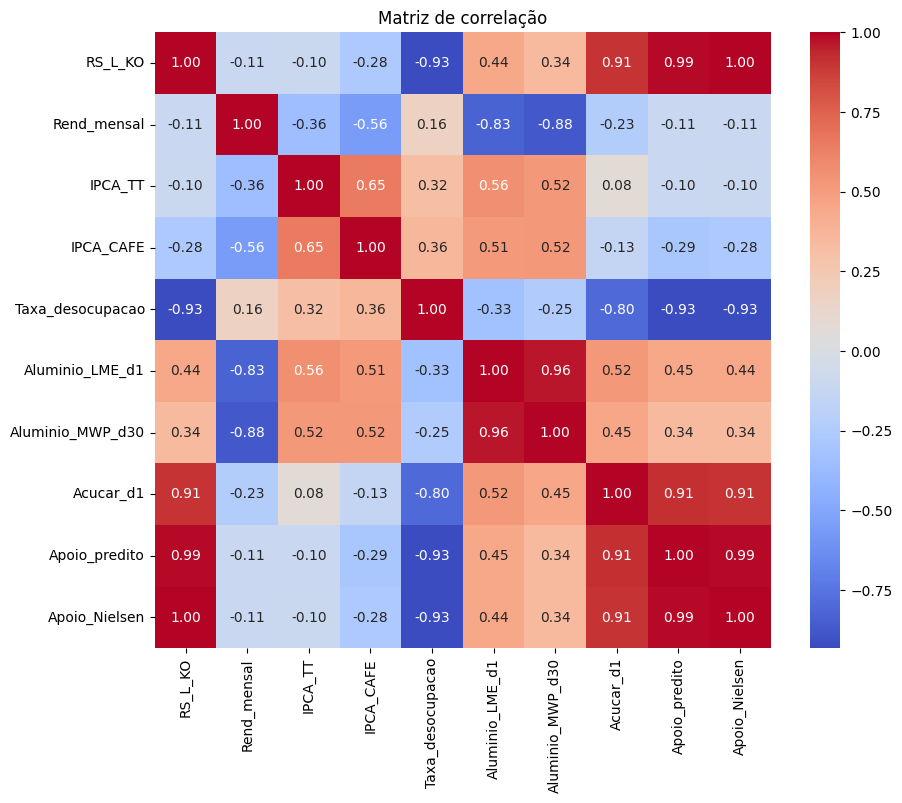

In [35]:
# Matriz de Correl e heatmap
corr = df_modelo[cols_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Matriz de correlação")
plt.show()

                            OLS Regression Results                            
Dep. Variable:          Apoio_Nielsen   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     3459.
Date:                Thu, 08 Jan 2026   Prob (F-statistic):           5.97e-50
Time:                        20:07:48   Log-Likelihood:                 60.493
No. Observations:                  55   AIC:                            -117.0
Df Residuals:                      53   BIC:                            -113.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0238      0.097      0.245

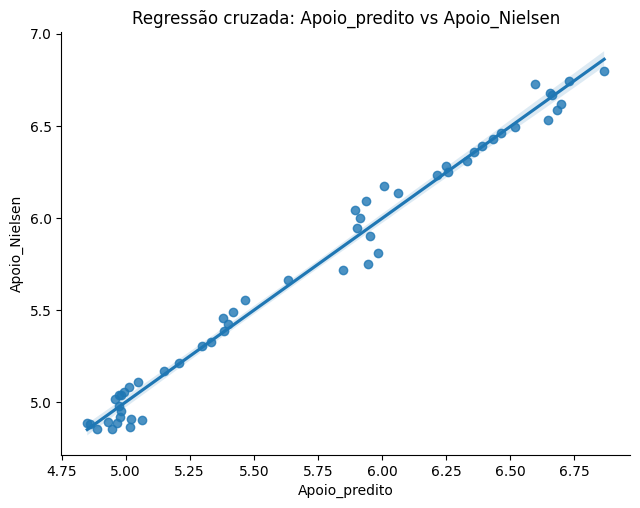

In [36]:
# Regressão cruzada simples 
X_cross = df_modelo[["Apoio_predito"]]
y_cross = df_modelo["Apoio_Nielsen"]

X_cross_sm = sm.add_constant(X_cross)
modelo_cross = sm.OLS(y_cross, X_cross_sm).fit()
print(modelo_cross.summary())

sns.lmplot(
    data=df_modelo,
    x="Apoio_predito",
    y="Apoio_Nielsen",
    height=5,
    aspect=1.3
)
plt.title("Regressão cruzada: Apoio_predito vs Apoio_Nielsen")
plt.show()

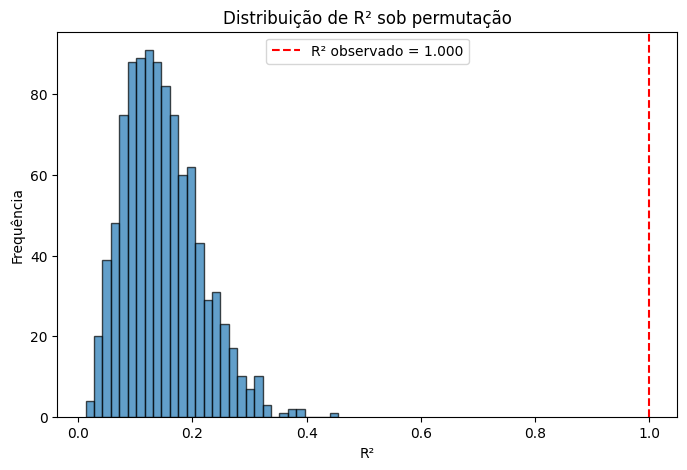

R² observado: 0.9999896698204852
p-valor aproximado (permutação): 0.0


In [39]:
# Ensaio permutado (significância R²)
def permutacao_r2(X, y, n_iter=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    r2_obs = r2_score(y, LinearRegression().fit(X, y).predict(X))
    r2_perm = []

    for _ in range(n_iter):
        y_perm = rng.permutation(y)
        r2_p = r2_score(y_perm, LinearRegression().fit(X, y_perm).predict(X))
        r2_perm.append(r2_p)

    return r2_obs, np.array(r2_perm)

r2_obs, r2_perm = permutacao_r2(X, y, n_iter=1000)

plt.figure(figsize=(8,5))
plt.hist(r2_perm, bins=30, alpha=0.7, edgecolor="black")
plt.axvline(r2_obs, color="red", linestyle="--", label=f"R² observado = {r2_obs:.3f}")
plt.title("Distribuição de R² sob permutação")
plt.xlabel("R²")
plt.ylabel("Frequência")
plt.legend()
plt.show()

p_val = (r2_perm >= r2_obs).mean()
print("R² observado:", r2_obs)
print("p-valor aproximado (permutação):", p_val)

In [41]:
# testes para investigação de overfitting (multicolinearidade/supercorrelação)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variavel"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(X.columns))]

print(vif_data)

           Variavel        VIF
0       Rend_mensal        inf
1           IPCA_TT        inf
2         IPCA_CAFE   2.830178
3  Taxa_desocupacao        inf
4   Aluminio_LME_d1        inf
5  Aluminio_MWP_d30        inf
6         Acucar_d1        inf
7     Apoio_predito        inf
8     Apoio_Nielsen  67.853152


C:\Users\jesse\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


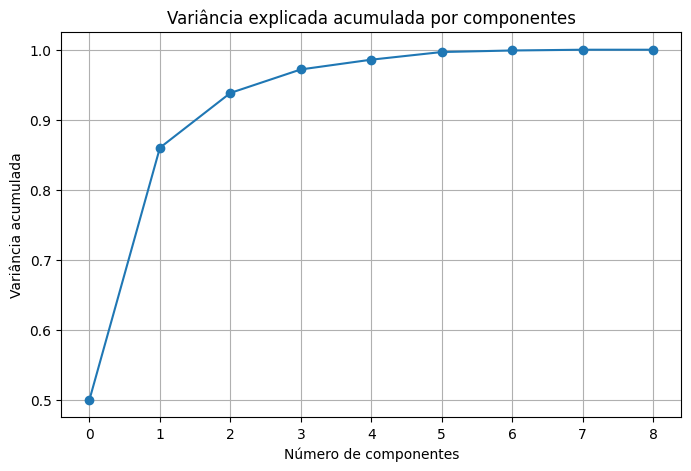

In [44]:
# Reduzindo dimensionalidade com PCA (Análise de componentes principais)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title("Variância explicada acumulada por componentes")
plt.xlabel("Número de componentes")
plt.ylabel("Variância acumulada")
plt.grid(True)
plt.show()

In [47]:
# Testando regressão regularizada com Ridge & lasso
from sklearn.linear_model import RidgeCV, LassoCV

ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge.fit(X_train, y_train)
print("Ridge R²:", ridge.score(X_test, y_test))

lasso = LassoCV(alphas=None, cv=5, max_iter=10000)
lasso.fit(X_train, y_train)
print("Lasso R²:", lasso.score(X_test, y_test))

# Verificando variáveis derivadas ou duplicidade natural

corr_check = df_modelo[["Apoio_predito", "Apoio_Nielsen"]].corr()
print(corr_check)

Ridge R²: 0.9999959711866362
Lasso R²: 0.8069162053542392
               Apoio_predito  Apoio_Nielsen
Apoio_predito       1.000000       0.992427
Apoio_Nielsen       0.992427       1.000000


C:\Users\jesse\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


In [49]:
# Aumentando precision variação cruzada
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print("R² médio (CV):", scores.mean())

R² médio (CV): 0.9983185408719459


In [52]:
# Algoritmo final do ensaio estatístico
# Visão variáveis Lasso após treinar o modelo: 

lasso = LassoCV(cv=5, max_iter=10000)
lasso.fit(X_train, y_train)

intercepto = lasso.intercept_
coeficientes = pd.Series(lasso.coef_, index=X.columns)

print("Intercepto:", intercepto)
print("\nCoeficientes do Lasso:")
print(coeficientes)

Intercepto: -5.1250480442750055

Coeficientes do Lasso:
Rend_mensal         0.002046
IPCA_TT             0.000000
IPCA_CAFE          -0.084618
Taxa_desocupacao    0.000000
Aluminio_LME_d1     0.001569
Aluminio_MWP_d30   -0.001146
Acucar_d1           0.000000
Apoio_predito       0.000000
Apoio_Nielsen       0.303934
dtype: float64


In [54]:
import numpy as np

# ============================
# 1. Coeficientes do modelo Lasso
# ============================

intercepto = -5.1250480442750055

coeficientes = {
    "Rend_mensal":        0.002046,
    "IPCA_CAFE":         -0.084618,
    "Aluminio_LME_d1":    0.001569,
    "Aluminio_MWP_d30":  -0.001146,
    "Apoio_Nielsen":      0.303934
}

# ============================
# 2. Função de predição
# ============================

def prever_preco_lasso(intercepto, coef_dict, **kwargs):
    """
    intercepto: valor do intercepto do modelo Lasso
    coef_dict: dicionário {variável: coeficiente}
    kwargs: valores das variáveis, ex:
        Rend_mensal=3131.38, IPCA_CAFE=0.33, ...
    """
    y_pred = intercepto
    
    for var, coef in coef_dict.items():
        valor = kwargs.get(var, 0)
        y_pred += coef * valor
    
    return y_pred

# ============================
# 3. Simulação com seus valores
# ============================

preco_predito = prever_preco_lasso(
    intercepto,
    coeficientes,
    Rend_mensal=3131.38,
    IPCA_CAFE=0.33,
    Aluminio_LME_d1=1616.86,
    Aluminio_MWP_d30=261.45,
    Apoio_Nielsen=6.90
)

print("Preço Predito (Lasso):", round(preco_predito, 2))

Preço Predito (Lasso): 5.59


In [58]:
# Treinando o modelo para extrair intercept Ridge
from sklearn.linear_model import RidgeCV
import pandas as pd

# ============================
# 1. Treinar modelo Ridge
# ============================

# Lista de alphas para o RidgeCV testar
alphas = [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

# ============================
# 2. Extrair intercepto e coeficientes
# ============================

intercepto_ridge = ridge.intercept_
coeficientes_ridge = pd.Series(ridge.coef_, index=X.columns)

print("=== Intercepto Ridge ===")
print(intercepto_ridge)

print("\n=== Coeficientes Ridge ===")
print(coeficientes_ridge)

=== Intercepto Ridge ===
-0.08249032414387703

=== Coeficientes Ridge ===
Rend_mensal         0.000028
IPCA_TT            -0.012750
IPCA_CAFE           0.001486
Taxa_desocupacao   -0.009029
Aluminio_LME_d1     0.000001
Aluminio_MWP_d30    0.000023
Acucar_d1           0.014842
Apoio_predito       0.196257
Apoio_Nielsen       0.801150
dtype: float64


In [63]:
import numpy as np

# ============================
# 1. Coeficientes do modelo Ridge
# ============================

intercepto_ridge = -0.08249032414387703

coeficientes_ridge = {
    "Rend_mensal":        0.000028,
    "IPCA_TT":           -0.012750,
    "IPCA_CAFE":          0.001486,
    "Taxa_desocupacao":  -0.009029,
    "Aluminio_LME_d1":    0.000001,
    "Aluminio_MWP_d30":   0.000023,
    "Acucar_d1":          0.014842,
    "Apoio_predito":      0.196257,
    "Apoio_Nielsen":      0.801150
}

# ============================
# 2. Função de predição Ridge
# ============================

def prever_preco_ridge(intercepto, coef_dict, **kwargs):
    """
    intercepto: valor do intercepto do modelo Ridge
    coef_dict: dicionário {variável: coeficiente}
    kwargs: valores das variáveis, ex:
        Rend_mensal=3131.38, IPCA_CAFE=0.33, ...
    """
    y_pred = intercepto
    
    for var, coef in coef_dict.items():
        valor = kwargs.get(var, 0)
        y_pred += coef * valor
    
    return y_pred

# ============================
# 3. Simulação final algoritmo
# ============================

preco_predito_ridge = prever_preco_ridge(
    intercepto_ridge,
    coeficientes_ridge,
    Rend_mensal=4131.38,
    IPCA_TT=0.43,
    IPCA_CAFE=0.43,
    Taxa_desocupacao=0.14,
    Aluminio_LME_d1=2616.86,
    Aluminio_MWP_d30=261.45,
    Acucar_d1=0.13,
    Apoio_predito=0,      # coloque o valor real se quiser testar
    Apoio_Nielsen=6.90
)

print("Preço Predito (Ridge):", round(preco_predito_ridge, 2))

Preço Predito (Ridge): 5.57


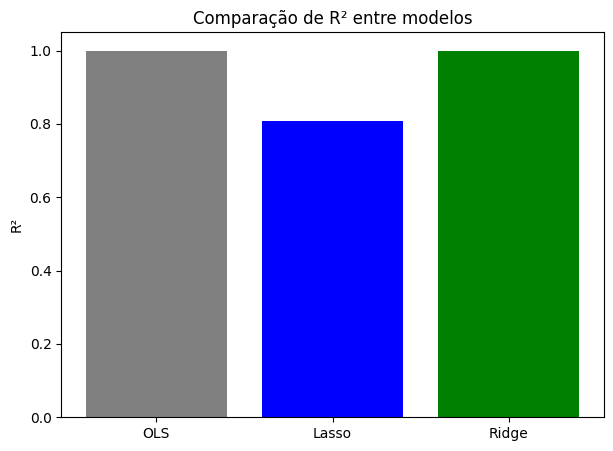

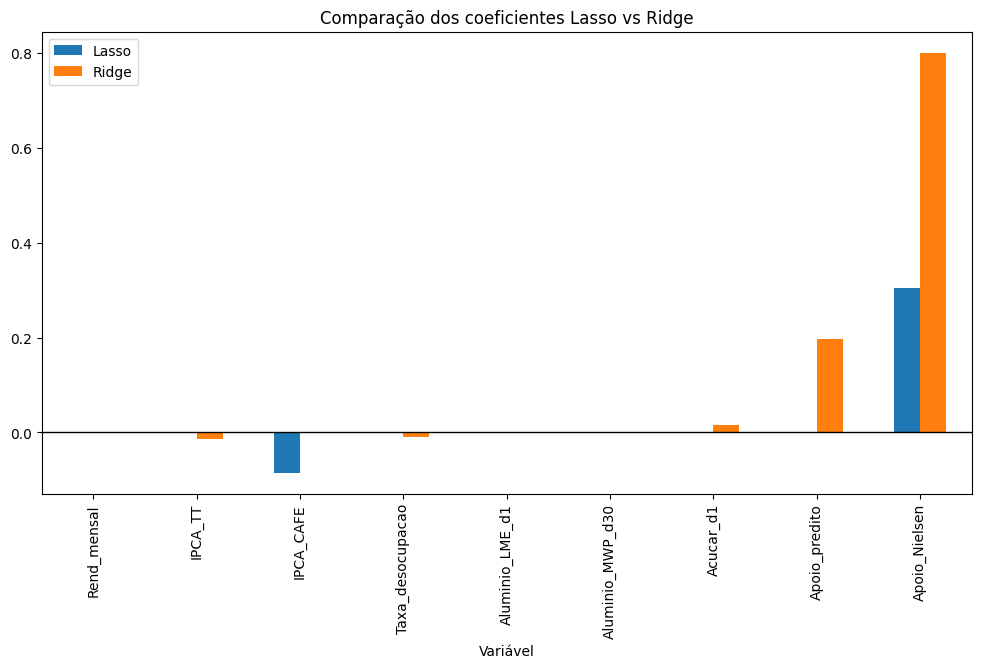

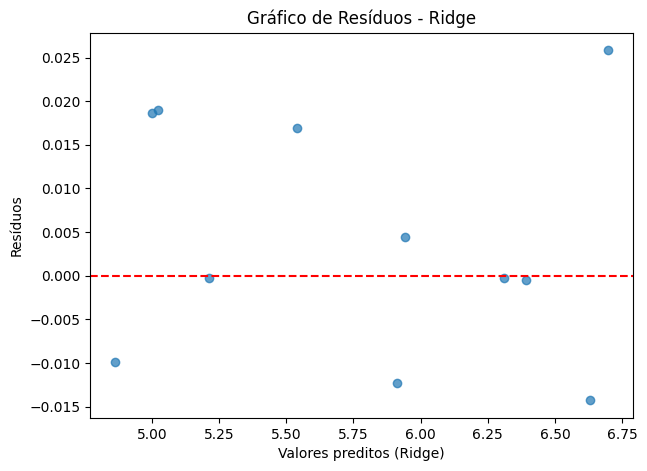

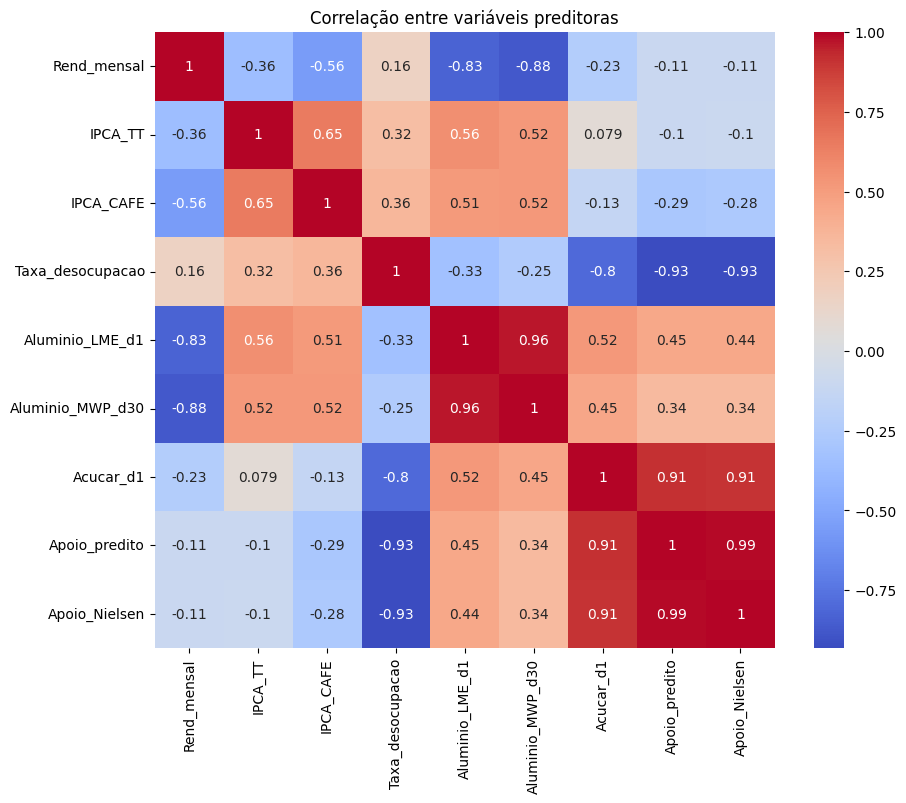

Ridge - R² médio (CV): -1.576430464587854
Lasso - R² médio (CV): -40.61557093229316


In [65]:
# Análise dos modelos

# Comparação
modelos = {
    "OLS": modelo_sm.rsquared,
    "Lasso": lasso.score(X_test, y_test),
    "Ridge": ridge.score(X_test, y_test)
}

plt.figure(figsize=(7,5))
plt.bar(modelos.keys(), modelos.values(), color=["gray","blue","green"])
plt.title("Comparação de R² entre modelos")
plt.ylabel("R²")
plt.show()

modelos

# Importância das variáveis
coef_df = pd.DataFrame({
    "Variável": X.columns,
    "Lasso": lasso.coef_,
    "Ridge": ridge.coef_
})

coef_df.set_index("Variável").plot(kind="bar", figsize=(12,6))
plt.title("Comparação dos coeficientes Lasso vs Ridge")
plt.axhline(0, color="black", linewidth=1)
plt.show()

# Análise residual
y_pred_ridge = ridge.predict(X_test)

residuos = y_test - y_pred_ridge

plt.figure(figsize=(7,5))
plt.scatter(y_pred_ridge, residuos, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valores preditos (Ridge)")
plt.ylabel("Resíduos")
plt.title("Gráfico de Resíduos - Ridge")
plt.show()

# Análise da Elasticidade
elasticidade = {}

for var in X.columns:
    media_x = df_modelo[var].mean()
    media_y = df_modelo["RS_L_KO"].mean()
    coef = ridge.coef_[X.columns.get_loc(var)]
    elasticidade[var] = coef * (media_x / media_y)

pd.DataFrame(elasticidade, index=["Elasticidade"]).T

# Análise da sensibilidade
def sensibilidade(modelo, var, base_valores, coef_dict, intercepto):
    valores = base_valores.copy()
    original = prever_preco_ridge(intercepto, coef_dict, **valores)
    
    valores[var] *= 1.01  # +1%
    novo = prever_preco_ridge(intercepto, coef_dict, **valores)
    
    return novo - original

base = {
    "Rend_mensal": 3131.38,
    "IPCA_TT": 0.43,
    "IPCA_CAFE": 0.33,
    "Taxa_desocupacao": 0.13,
    "Aluminio_LME_d1": 1616.86,
    "Aluminio_MWP_d30": 261.45,
    "Acucar_d1": 0.13,
    "Apoio_predito": 0,
    "Apoio_Nielsen": 6.90
}

sens = {var: sensibilidade(ridge, var, base, coeficientes_ridge, intercepto_ridge) for var in X.columns}

pd.DataFrame(sens, index=["Impacto (+1%)"]).T

# Heatmap da correl
plt.figure(figsize=(10,8))
sns.heatmap(df_modelo[X.columns].corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre variáveis preditoras")
plt.show()

# Validação cruzada
from sklearn.model_selection import cross_val_score

scores_ridge = cross_val_score(ridge, X, y, cv=5, scoring="r2")
scores_lasso = cross_val_score(lasso, X, y, cv=5, scoring="r2")

print("Ridge - R² médio (CV):", scores_ridge.mean())
print("Lasso - R² médio (CV):", scores_lasso.mean())